# Accuracy Notes and Code
A short notebook about the accuracy data.

In [37]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [38]:
import pathlib

cwd = pathlib.Path().resolve()
CSV_PATH = None
ROOT = None
for p in [cwd] + list(cwd.parents):
    candidate = p / 'a4s-eval' / 'tests' / 'data' / 'measures' / 'accuracy.csv'
    if candidate.exists():
        CSV_PATH = str(candidate)
        ROOT = str(p / 'a4s-eval')
        break
    candidate2 = p / 'tests' / 'data' / 'measures' / 'accuracy.csv'
    if candidate2.exists():
        CSV_PATH = str(candidate2)
        ROOT = str(p)
        break

if CSV_PATH is None:
    ROOT = str(cwd)
    CSV_PATH = os.path.join(ROOT, 'tests', 'data', 'measures', 'accuracy.csv')

RESULTS_DIR = os.path.join(ROOT, 'notebook_results')
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Looking for:', CSV_PATH)


Looking for: /home/halefoam/MSc in Cybersecurity/Second semester/a4s_final/a4s-eval/tests/data/measures/accuracy.csv


In [39]:
df = None
if os.path.exists(CSV_PATH):
    try:
        df = pd.read_csv(CSV_PATH)
        print('Loaded CSV with shape', df.shape)
    except Exception as e:
        print('Failed to read CSV:', e)

if df is not None and not df.empty:
    if 'time' in df.columns:
        df['time'] = pd.to_datetime(df['time'], errors='coerce')
        df = df.dropna(subset=['time'])
        df = df[df['time'].dt.year == 2026]
    elif 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
        df = df.dropna(subset=['timestamp'])
        df = df[df['timestamp'].dt.year == 2026]
    print('filtering shape:', df.shape)
    display(df.head())
    display(df.dtypes)
else:
    print('No suitable CSV found — using a demo classification dataset (iris).')
    data = load_iris(as_frame=True)
    X = data.data
    y = data.target
    df = pd.concat([X, y.rename('target')], axis=1)
    display(df.head())

Loaded CSV with shape (799, 4)
filtering shape: (777, 4)


,name,score,time,feature_pid
22,accuracy,0.7145,2026-04-01 16:07:13.492932,NaN
23,accuracy,0.7400,2026-04-01 16:07:13.860242,NaN
24,accuracy,0.7220,2026-04-01 16:07:14.031371,NaN
25,accuracy,0.7080,2026-04-01 16:07:14.054245,NaN
26,accuracy,0.7080,2026-04-01 16:07:14.076730,NaN


name                   object
score                 float64
time           datetime64[ns]
feature_pid           float64
dtype: object

In [40]:
metrics = {}
if any(c in df.columns for c in ('score','value','metric','name')):
    if 'score' in df.columns and 'name' in df.columns:
        acc_rows = df[df['name'].str.lower() == 'accuracy']['score'].dropna().astype(float)
    elif 'value' in df.columns and 'metric' in df.columns:
        acc_rows = df[df['metric'].str.lower() == 'accuracy']['value'].dropna().astype(float)
    elif 'score' in df.columns:
        acc_rows = pd.to_numeric(df['score'], errors='coerce').dropna()
    elif 'value' in df.columns:
        acc_rows = pd.to_numeric(df['value'], errors='coerce').dropna()
    else:
        acc_rows = pd.Series(dtype=float)
    if len(acc_rows) > 0:
        metrics['accuracy'] = float(acc_rows.mean())
        metrics['accuracy_median'] = float(acc_rows.median())
        metrics['accuracy_std'] = float(acc_rows.std(ddof=1)) if len(acc_rows) > 1 else 0.0
        print('Computed accuracy from measure rows:', metrics['accuracy'])
    else:
        pass
if 'accuracy' not in metrics:
    if ('y_true' in df.columns and 'y_pred' in df.columns) or ('y_true' in df.columns and 'prediction' in df.columns):
        y_true = df['y_true']
        y_pred = df['y_pred'] if 'y_pred' in df.columns else df['prediction']
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        report = classification_report(y_true, y_pred, output_dict=True)
        metrics.update({'accuracy': acc})
        print('Computed accuracy from provided predictions:', acc)
    elif 'correct' in df.columns:
        acc = df['correct'].mean()
        metrics.update({'accuracy': float(acc)})
        print('Computed accuracy from "correct" column:', acc)
    else:
        possible_targets = [c for c in df.columns if c.lower() in ('target', 'label', 'y', 'class')]
        if len(possible_targets) > 0:
            target_col = possible_targets[0]
            X = df.drop(columns=[target_col])
            y = df[target_col]
            print('Detected target column:', target_col)
        else:
            print('No obvious target column found; generating a small classification dataset')
            X, y = make_classification(n_samples=300, n_features=6, n_informative=4, n_classes=3, random_state=42)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)
        metrics.update({'accuracy': float(acc)})
        print('Trained RandomForest and computed test accuracy:', acc)

Computed accuracy from measure rows: 0.7145


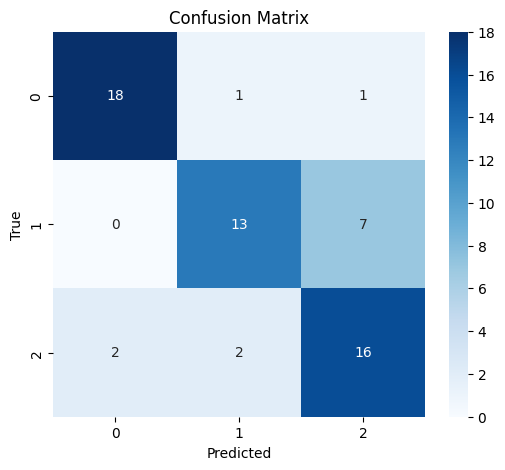

Per-class accuracy (recall): {'class_0': 0.9, 'class_1': 0.65, 'class_2': 0.8}

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        20
           1       0.81      0.65      0.72        20
           2       0.67      0.80      0.73        20

    accuracy                           0.78        60
   macro avg       0.79      0.78      0.78        60
weighted avg       0.79      0.78      0.78        60



In [41]:
if 'cm' in locals():
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Per-class recall (class-wise accuracy)
    recalls = np.diag(cm) / cm.sum(axis=1).astype(float)
    per_class = {f'class_{i}': float(v) for i,v in enumerate(recalls)}
    print('Per-class accuracy (recall):', per_class)
    metrics.update({'per_class_accuracy': per_class})

    # classification report if available
    try:
        print('\nClassification report:')
        print(classification_report(y_test if 'y_test' in locals() else y_true, y_pred))
    except Exception:
        pass
else:
    print('No confusion matrix available to plot.')

In [42]:
if 'X' in locals() and 'y' in locals():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X, y, cv=cv, scoring='accuracy')
    mean_acc = scores.mean()
    std_acc = scores.std(ddof=1)
    # 95% CI using t-approx (large-sample normal approx here)
    ci95 = 1.96 * std_acc / np.sqrt(len(scores))
    print(f'CV accuracies: {scores}')
    print(f'Mean accuracy: {mean_acc:.4f} ± {ci95:.4f} (95% CI)')
    metrics.update({'cv_mean_accuracy': float(mean_acc), 'cv_std': float(std_acc), 'cv_95ci': float(ci95)})
else:
    print('No feature matrix available for cross-validation.')

CV accuracies: [0.76666667 0.83333333 0.81666667 0.88333333 0.75      ]
Mean accuracy: 0.8100 ± 0.0469 (95% CI)


In [43]:
if ('y_test' in locals() or 'y_true' in locals()) and 'y_pred' in locals():
    y_t = y_test if 'y_test' in locals() else y_true
    precision, recall, f1, support = precision_recall_fscore_support(y_t, y_pred, average=None)
    macro_prec = precision_recall_fscore_support(y_t, y_pred, average='macro')[0]
    micro_prec = precision_recall_fscore_support(y_t, y_pred, average='micro')[0]
    print('Per-class precision:', precision)
    print('Per-class recall:', recall)
    print('Per-class f1:', f1)
    print('\nMacro-averaged scores (precision/recall/f1):', precision_recall_fscore_support(y_t, y_pred, average='macro'))
    print('\nNote: Accuracy can be misleading on imbalanced datasets; compare these metrics.')
else:
    print('No predictions available to compute precision/recall/F1.')

Per-class precision: [0.9        0.8125     0.66666667]
Per-class recall: [0.9  0.65 0.8 ]
Per-class f1: [0.9        0.72222222 0.72727273]

Macro-averaged scores (precision/recall/f1): (0.7930555555555555, 0.7833333333333333, 0.7831649831649831, None)

Note: Accuracy can be misleading on imbalanced datasets; compare these metrics.


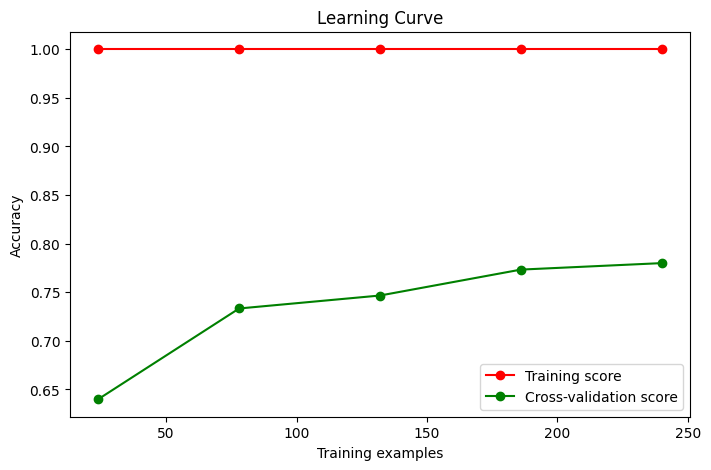

In [44]:
if 'X' in locals() and 'y' in locals():
    from sklearn.model_selection import learning_curve
    estimator = RandomForestClassifier(n_estimators=100, random_state=42)
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=1)
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation score')
    plt.xlabel('Training examples')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')
    plt.title('Learning Curve')
    plt.show()
else:
    print('No dataset available to plot learning curve.')

In [45]:
summary_csv = os.path.join(RESULTS_DIR, 'accuracy_summary.csv')
summary_json = os.path.join(RESULTS_DIR, 'accuracy_summary.json')
with open(summary_json, 'w') as fh:
    json.dump(metrics, fh, indent=2)
flat = {k: v if isinstance(v, (int, float, str)) else json.dumps(v) for k,v in metrics.items()}
pd.DataFrame([flat]).to_csv(summary_csv, index=False)
print('Saved metrics to', summary_csv, 'and', summary_json)

test_dir = os.path.join(ROOT, 'tests')
os.makedirs(test_dir, exist_ok=True)
test_file = os.path.join(test_dir, 'test_accuracy_helper.py')
test_code = '''
import numpy as np
from sklearn.metrics import confusion_matrix


def manual_accuracy_from_cm(cm):
    tp_tn = cm.trace()
    total = cm.sum()
    return tp_tn / total


def test_manual_accuracy():
    cm = np.array([[5, 2],[1, 12]])
    # manual: (5+12)/(5+2+1+12)=17/20=0.85
    assert abs(manual_accuracy_from_cm(cm) - 0.85) < 1e-6
'''
with open(test_file, 'w') as fh:
    fh.write(test_code)
print('Wrote unit test to', test_file)

Saved metrics to /home/halefoam/MSc in Cybersecurity/Second semester/a4s_final/a4s-eval/notebook_results/accuracy_summary.csv and /home/halefoam/MSc in Cybersecurity/Second semester/a4s_final/a4s-eval/notebook_results/accuracy_summary.json
Wrote unit test to /home/halefoam/MSc in Cybersecurity/Second semester/a4s_final/a4s-eval/tests/test_accuracy_helper.py
